# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Anneliese Tarzian
* Username: atarzian
* Student number: S6199984
* Group (AS1, etc.): AS1

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

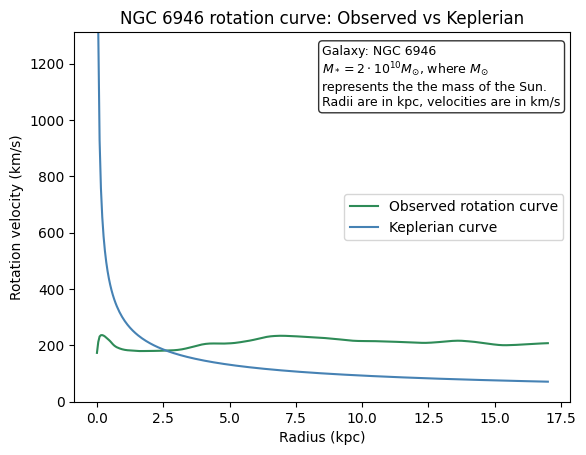

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Getting the observational rotation-curve data for NGC 6946
radius_kpc, v_obs = np.loadtxt("rotcur.dat", unpack=True, comments='#')

# Constants and unit conversion
M_star = 2.0e10                 # in solar masses
G = 4.3e-3                      # in pc * (solar masses)^-1 * (km/s)^2
radius_pc = radius_kpc * 1000   # from kpc in pc


# Calculating the Keplerian rotation curve and avoiding division by 0
safe = []

for i in range(len(radius_pc)):
    if radius_pc[i] > 0:
        
        safe.append(radius_pc[i])

r_safe = np.array(safe)

v_kepl = np.sqrt((4.3e-3 * M_star) / r_safe)


# Saving the data to a text file and then reloading it
kepl_data = np.column_stack(((r_safe / 1000), v_kepl))
np.savetxt(
    "keplerian_curve.txt",
    kepl_data
)

r_loaded, v_loaded = np.loadtxt("keplerian_curve.txt", unpack=True)

# Plotting the observed and Keplerian rotation curves
plt.plot(radius_kpc, v_obs, color="seagreen", label="Observed rotation curve")
plt.plot(r_loaded, v_loaded, color="steelblue", label="Keplerian curve")

plt.xlabel("Radius (kpc)")
plt.ylabel("Rotation velocity (km/s)")

plt.ylim(0, np.max(v_loaded))

# Annotating with galaxy and mass information
annotation_text = (
    "Galaxy: NGC 6946\n"
    "$M_* = 2 \cdot 10^{10} M_{\odot}$, where $M_{\odot}$\n"
    "represents the the mass of the Sun.\n"
    "Radii are in kpc, velocities are in km/s"

)
plt.annotate(
    annotation_text,
    xy=(0.5, 0.8),
    xycoords="axes fraction",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.legend()
plt.title("NGC 6946 rotation curve: Observed vs Keplerian")
plt.show()

# Comments

# In a spiral galaxy like NGC 6946, the observed rotation curve remains almost flat at large radii,
# while the Keplerian curve declines with r^(-1/2). This difference between the flat observed curve 
# and the declining Keplerian curve is usually interpreted as evidence for a dark matter.


In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

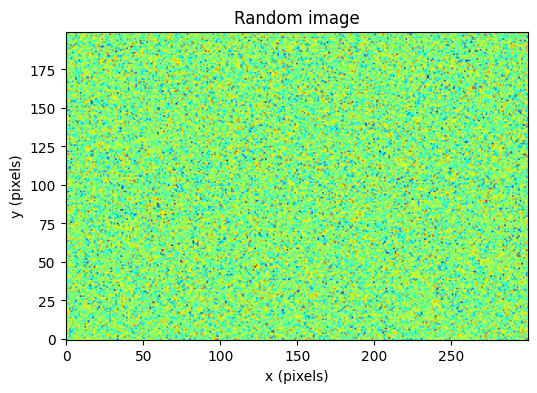

Random slice position: rows 123:153, columns 33:63
Slice mean = -0.02
Slice standard deviation = 0.96


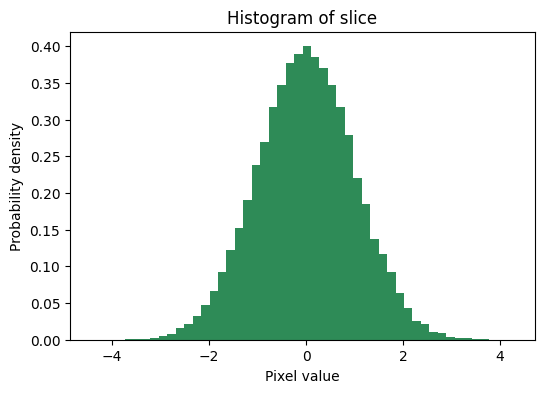

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Making the 2D array
img = np.random.normal(0.0, 1.0, (200, 300))

# Plotting the image with jet color map + color bar
plt.figure(figsize=(8, 4))
plt.imshow(img, cmap='jet', origin='lower')
plt.title("Random image")
plt.xlabel("x (pixels)")
plt.ylabel("y (pixels)")
plt.show()

# Randomly choosing a 30x30 slice such that the 30x30 window stays inside the image
row_start = np.random.randint(0, 171)  
col_start = np.random.randint(0, 271)  
row_end = row_start + 30
col_end = col_start + 30

sliced = img[row_start:row_end, col_start:col_end]

mean = sliced.mean()
std = sliced.std()

# Yes, the mean and standard deviation are what I expected because 
# they are roughly the same s the given ones in the random numpy array
print(f"Random slice position: rows {row_start}:{row_end}, columns {col_start}:{col_end}")
print(f"Slice mean = {mean:.2f}")
print(f"Slice standard deviation = {std:.2f}")

# Making histogram of all image values in 50 bins
img_flat = img.flatten()

plt.figure(figsize=(6, 4))
plt.hist(img_flat, bins=50, density=True, color='seagreen')
plt.xlabel('Pixel value')
plt.ylabel('Probability density')
plt.title('Histogram of slice')
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

AstroEllipse center = (0.0, 0.0), semi major axis = 3.0, semi minor axis = 2.0, position angle = 0.0 degrees
Area of the ellipse = 18.85
Perimeter of the ellipse = 15.87


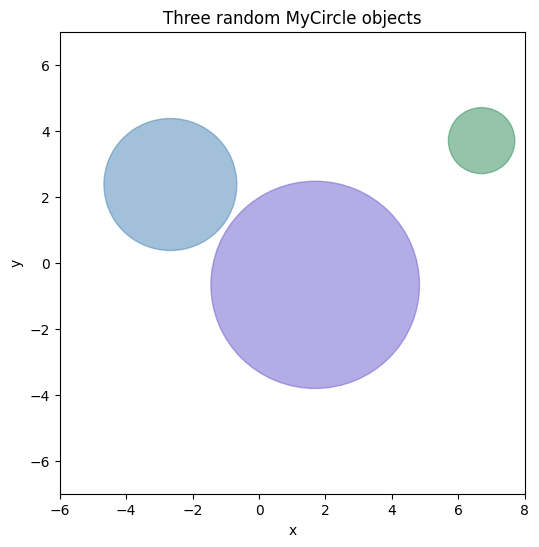

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert semi_major >= semi_minor  # Prerequisite to make angle unambiguous
        self.xc = xc
        self.yc = yc
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.position_angle = position_angle  # in degrees 

        XY = (xc, yc)              # MPL requires center as a tuple
        angle_mpl = position_angle # angle in degrees for Matplotlib
        height = 2.0 * semi_major  # height: along vertical axis (unrotated)
        width  = 2.0 * semi_minor  # width:  along horizontal axis (unrotated)

        super().__init__(XY, width, height, angle=angle_mpl, **args)

    # Creating the area, perimeter and string methods
    def area(self):
        """Return the area of the ellipse."""
        return math.pi * self.semi_major * self.semi_minor
    
    def perimeter(self):
        """Return the perimeter using Ramanujan's approximation."""
        a = self.semi_major
        b = self.semi_minor
        return math.pi * (3*(a + b) - math.sqrt((3*a + b)*(a + 3*b)))
    
    def __str__(self):
        return (f"AstroEllipse center = ({self.xc}, {self.yc}), semi major axis = {self.semi_major}, semi minor axis = {self.semi_minor}, position angle = {self.position_angle} degrees")

# The example with semi major = 3 and semi minor = 2
example = AstroEllipse(0.0, 0.0, 3.0, 2.0, 0.0)

print(example)                
print(f"Area of the ellipse = {example.area():.2f}")
print(f"Perimeter of the ellipse = {example.perimeter():.2f}")

# Creating MyCircle using AstroEllipse
class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, semi_major=radius, semi_minor=radius,
                         position_angle=0.0, **args)
        self.radius = radius

# Plotting the 3 circles with random centers and radii using axes object
cent_x = [-2.67, 6.7, 1.69]     
cent_y = [2.37, 3.7, -0.67]      
radii = [2, 1, 3.14]

colors = ['steelblue', 'seagreen', 'slateblue']

fig, ax = plt.subplots(figsize=(6, 6))

circles = []
for i in range(3):
    c = MyCircle(cent_x[i], cent_y[i], radii[i],
                 edgecolor=colors[i],
                 facecolor=colors[i],
                 alpha=0.5)
    
    circles.append(c)
    ax.add_patch(c)

ax.set_xlim(-6, 8)
ax.set_ylim(-7, 7)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Three random MyCircle objects")

plt.show()


In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

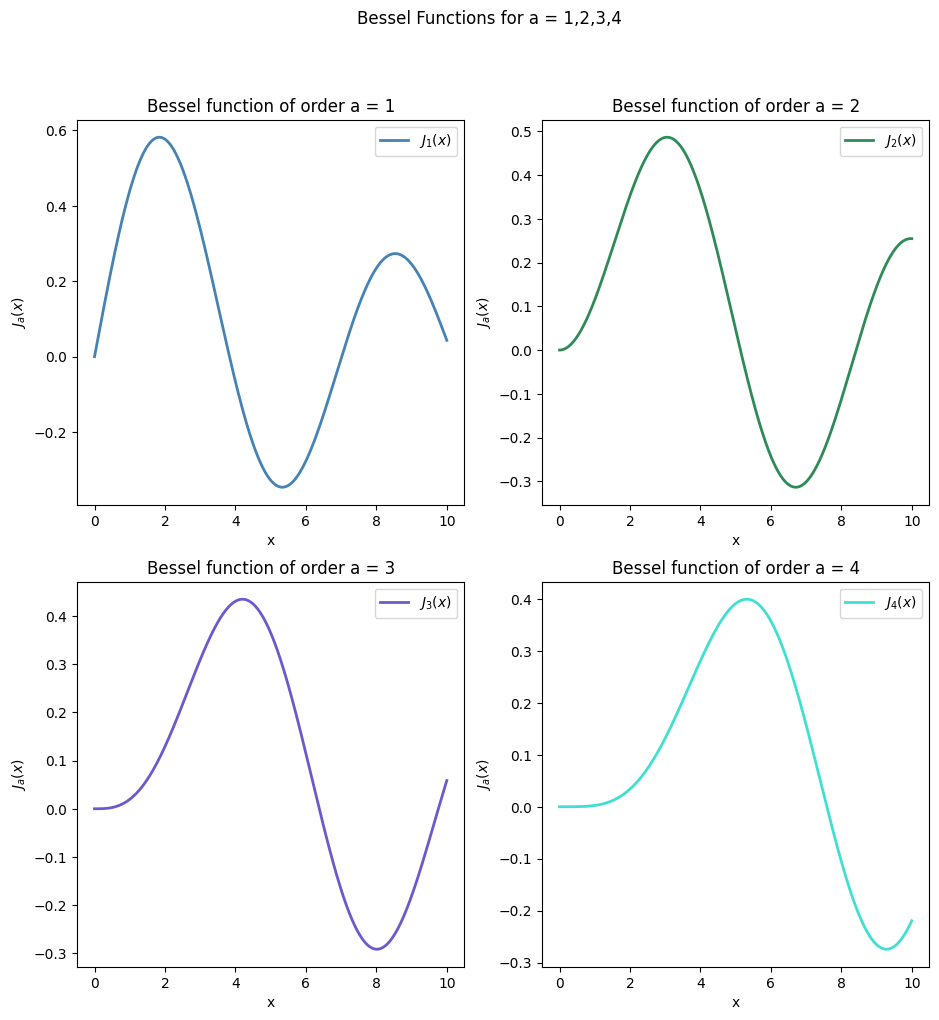

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv 

# Object-Oriented plotting, creating the figure with 2x2 subplot mosaic
fig, ax = plt.subplots(2, 2, figsize=(11, 11))

# Getting the values for x and a
x = np.linspace(0, 10, 1000)
orders = [1, 2, 3, 4]

# Flatten axes array for easier indexing
axes = ax.flatten()

colors = ['steelblue', 'seagreen', 'slateblue', 'turquoise']

# Computting and plotting the bechamel function
for i, a in enumerate(orders):
    y = jv(a, x)
    axes[i].plot(x, y, lw=2, color=colors[i], label=f"$J_{a}(x)$")
    
    # Axis labels and title for each subplot
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("$J_a(x)$")
    axes[i].set_title(f"Bessel function of order a = {a}")
    axes[i].legend()

# The global figure title
fig.suptitle("Bessel Functions for a = 1,2,3,4")

# Saving as transparent PNG and then showing the plot
plt.savefig("bessel.png", dpi=200, transparent=True)
plt.show()


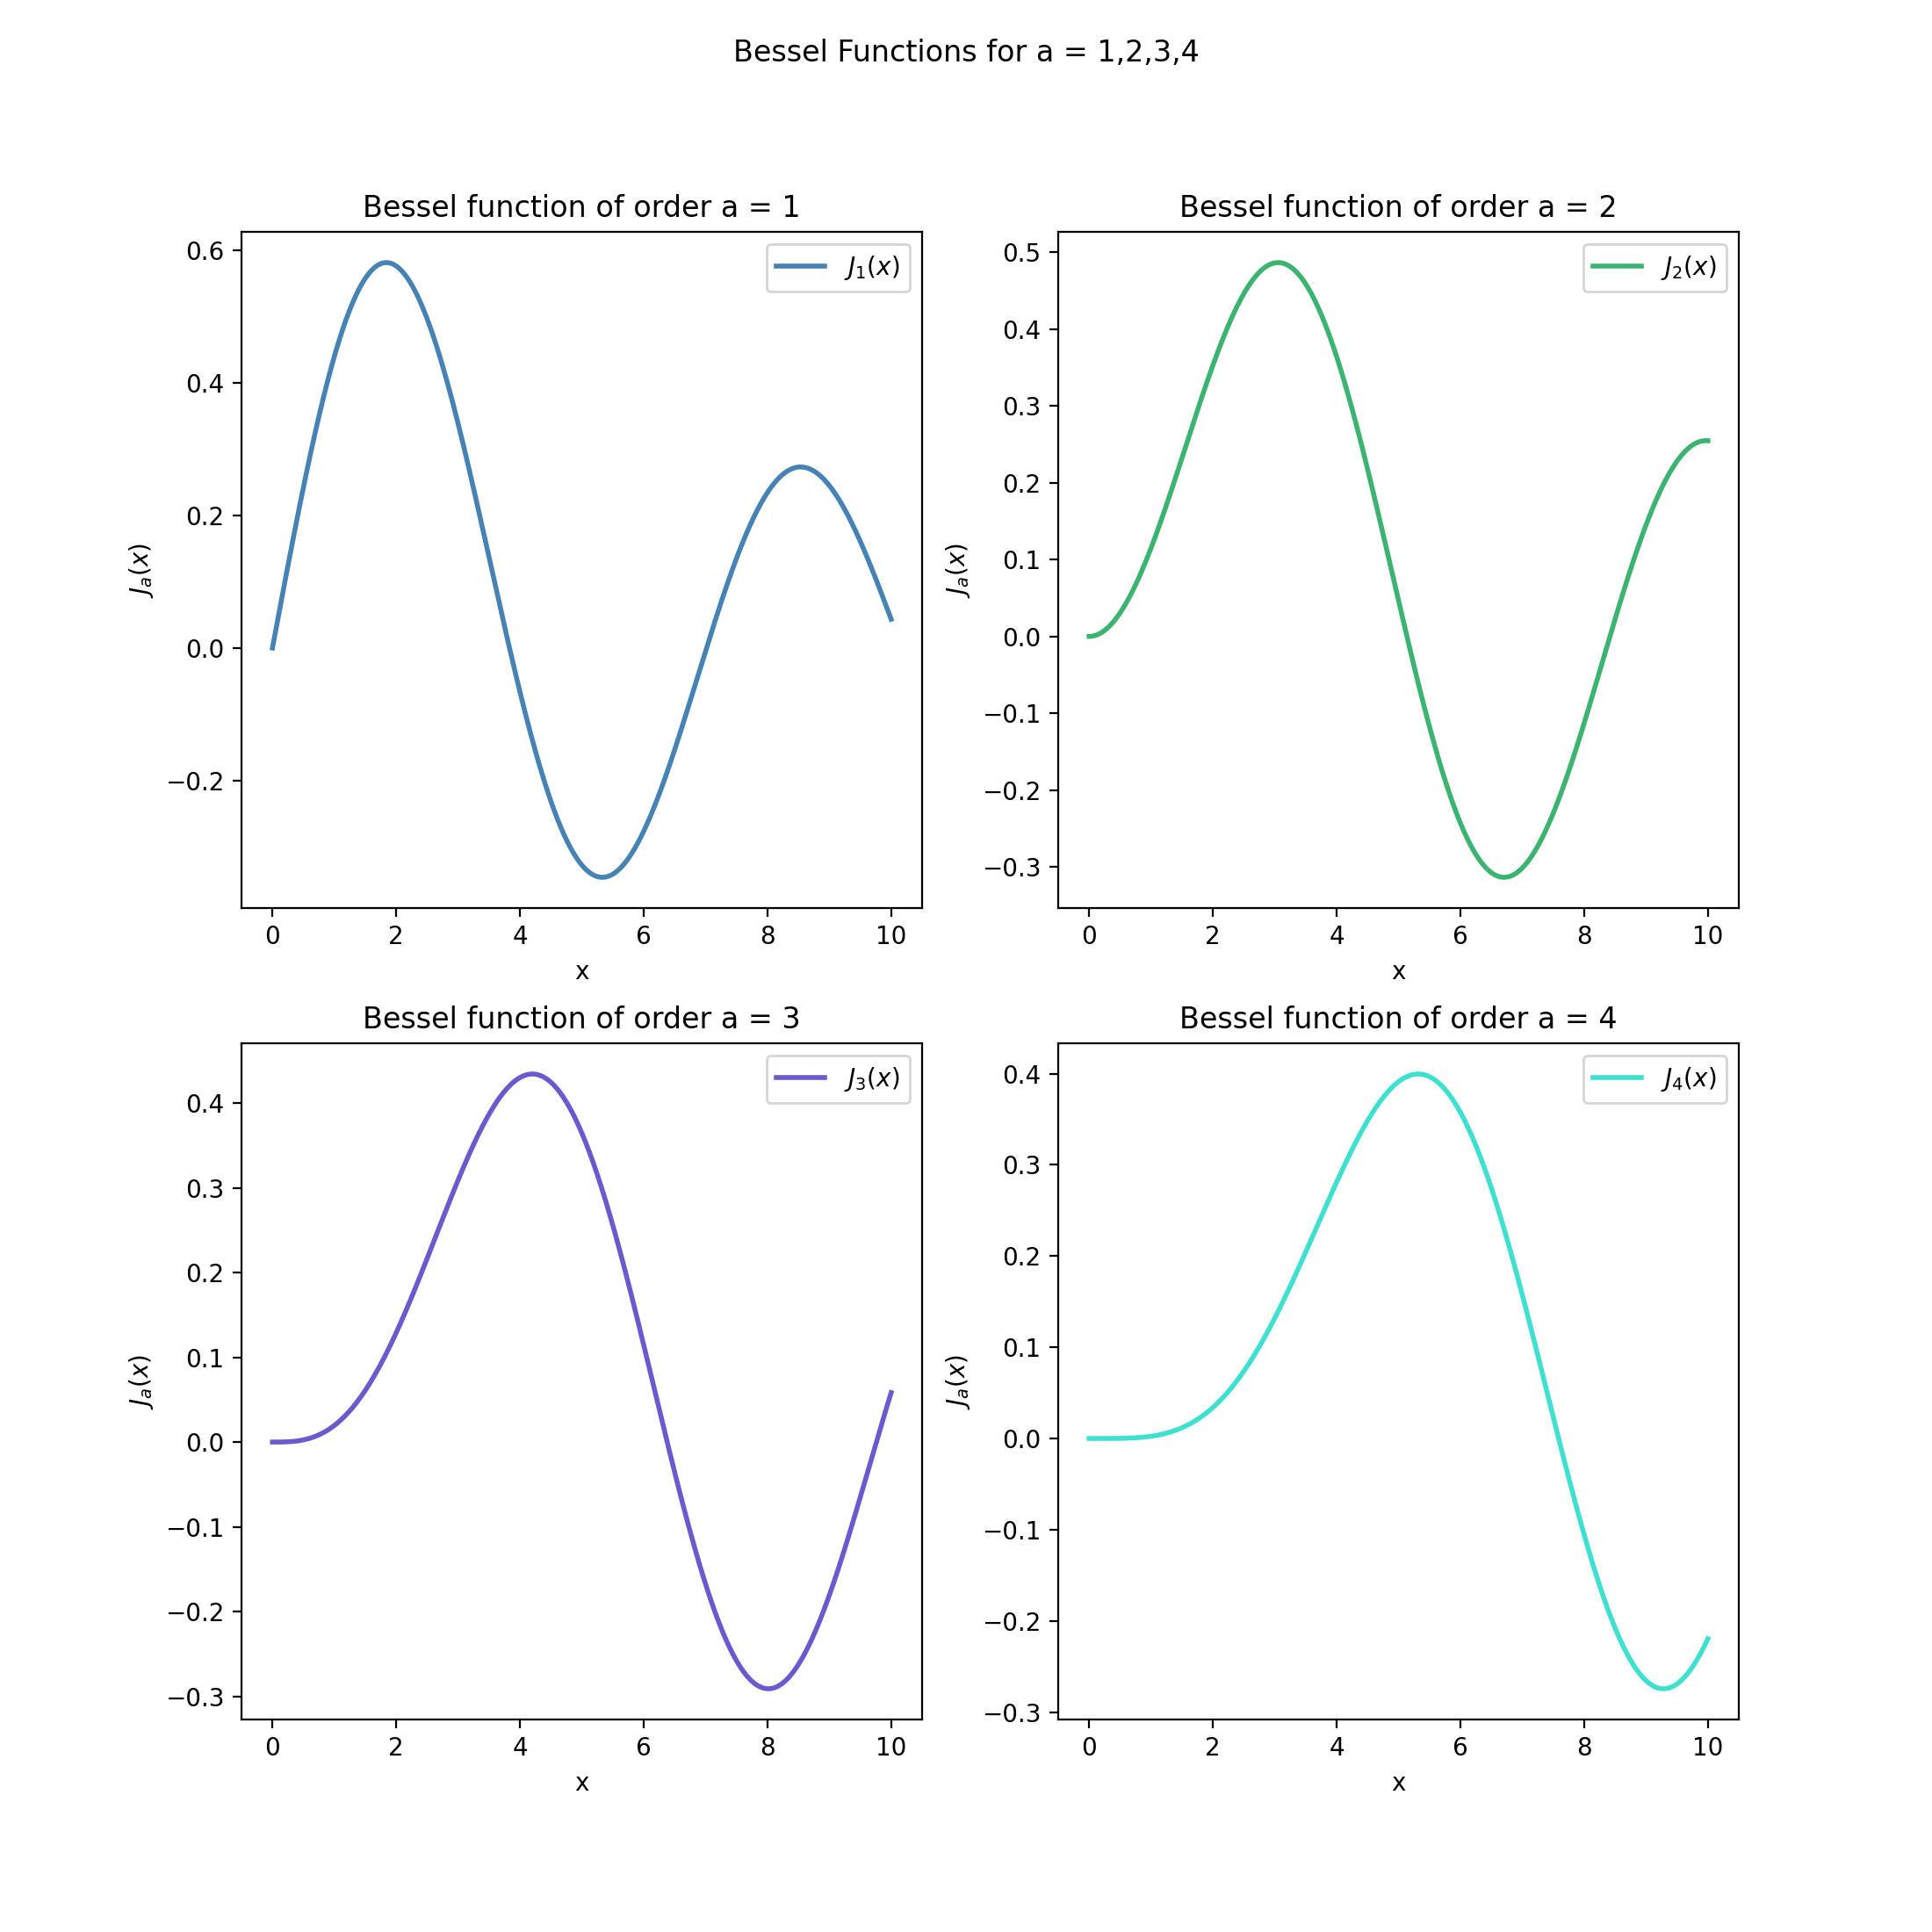

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

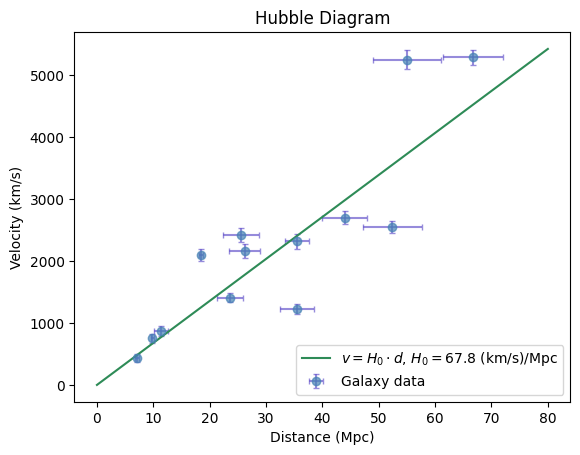

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Unpacking the data using slice
data = [
    18.49,    2094.75,  0.3,    100,
    35.48,    2320.87,  2.2,    120,
    35.48,    1224.9,   3.0,    80,
    11.34,    872.13,   1.2,    80,
    7.12,     432.2,    0.4,    70,
    9.82,     751,      0.3,    75,
    23.66,    1410,     2.3,    70,
    44,       2700,     4.0,    110,
    66.7,     5292,     5.3,    120,
    52.4,     2550,     5.2,    100,
    55,       5253,     6.1,    150,
    25.6,     2419,     3.2,    110,
    26.19,    2158,     2.8,    110
]

d = np.array(data[0::4])     # d(Mpc): indices 0,4,8...
v = np.array(data[1::4])     # v(km/s): indices 1,5,9...
derr = np.array(data[2::4])  # error d: indices 2,6,10...
verr = np.array(data[3::4])  # error v: indices 3,7,11...

# Creating figure and axis and plotting the data points WITH error bars
fig, ax = plt.subplots()

ax.errorbar(d, v, xerr=derr, yerr=verr, fmt='o', color='steelblue', 
           ecolor='slateblue', alpha=0.7, capsize=2, label='Galaxy data')

# Plotting the Hubble relation
H0 = 67.8  # units in (km/s)/Mpc
d_line = np.linspace(0, 80, 100)
v_line = H0 * d_line

ax.plot(d_line, v_line, color='seagreen', 
label=r'$v = H_0 \cdot d$, $H_0 = 67.8$ (km/s)/Mpc')

# Annotations and formatting
ax.set_xlabel("Distance (Mpc)")
ax.set_ylabel("Velocity (km/s)")
ax.set_title("Hubble Diagram")
ax.legend()

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")